In [1]:
print("hi")

hi


In [28]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal


In [40]:
class maths_state(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    discriminant:float
    disc_type:Literal['real_roots','equal_roots','no_real_roots']
    root1:float
    root2:float
    summary:str


In [41]:
graph=StateGraph(maths_state)


In [42]:
def calculate_discriminant(state:maths_state):
    a=state['a']
    b=state['b']
    c=state['c']
    equation=f'{a}X^2 + {b}X + {c}=0'
    disc=((b**2)-(4*a*c))
    return {'discriminant':disc,'equation':equation}

def calculate_real_roots(state:maths_state):
    a=state['a']
    b=state['b']
    c=state['c']
    e=state['equation']
    disc=state['discriminant']
    root1=(-b+(disc**0.5))/(2*a)
    root2=(-b+(disc**0.5))/(2*a)
    summary=f'the roots for the equation {e} are real and different. They are {root1} and {root2}'
    return {'summary':summary}


def calculate_equal_roots(state:maths_state):
    a=state['a']
    b=state['b']
    e=state['equation']
    root=(-b)/(2*a)
    summary=f'the roots for the equation {e} are the real and equal root. it is {root}'
    return {'summary':summary}

def no_real_roots(state:maths_state):
    e=state['equation']
    summary=f'the equation {e} has no real roots'
    return {'summary':summary}

def roots_summary(state:maths_state):
    print(state['summary'])


def check_condition(state:maths_state) -> Literal["calculate_real_roots","calculate_equal_roots","no_real_roots"]:
    disc=state['discriminant']
    if disc>0:
        return "calculate_real_roots"
    elif disc==0:
        return "calculate_equal_roots"
    else:
        return "no_real_roots"



In [43]:
# defining the nodes
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("calculate_real_roots",calculate_real_roots)
graph.add_node("calculate_equal_roots",calculate_equal_roots)
graph.add_node("no_real_roots",no_real_roots)
graph.add_node('roots_summary',roots_summary)


#defining the edges

graph.add_edge(START,"calculate_discriminant")

# edge with condition
graph.add_conditional_edges("calculate_discriminant",check_condition)
graph.add_edge("calculate_real_roots",'roots_summary')
graph.add_edge("calculate_equal_roots",'roots_summary')
graph.add_edge("no_real_roots",'roots_summary')
graph.add_edge('roots_summary',END)


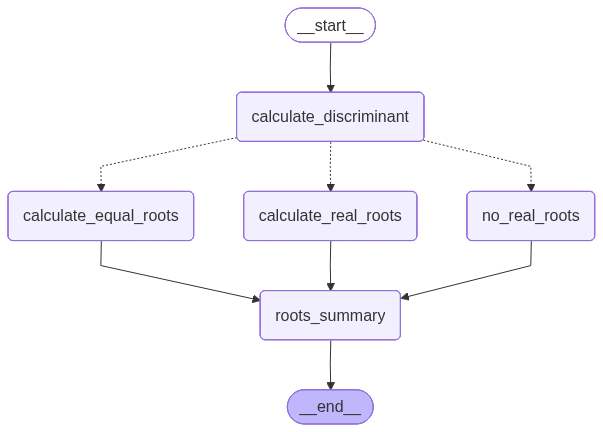

In [44]:
workflow=graph.compile()

workflow

In [45]:
initial_state={'a':1,'b':0,'c':-16}

output=workflow.invoke(initial_state)
output

the roots for the equation 1X^2 + 0X + -16=0 are real and different. They are 4.0 and 4.0


{'a': 1,
 'b': 0,
 'c': -16,
 'equation': '1X^2 + 0X + -16=0',
 'discriminant': 64,
 'summary': 'the roots for the equation 1X^2 + 0X + -16=0 are real and different. They are 4.0 and 4.0'}

In [46]:
state=maths_state(**output)
state['summary']

'the roots for the equation 1X^2 + 0X + -16=0 are real and different. They are 4.0 and 4.0'